In [2]:
import torch
import torch.nn as nn
import numpy as np
from matplotlib import pyplot as plt

from TrainHelpers import get_mnist
from torch.utils.data import DataLoader, Dataset
from TorchAutoencoders import TorchNN, TorchAutoencoder, LeNet5, TorchVAE
%load_ext autoreload
%autoreload 2

In [3]:
train_data, train_labels, test_data, test_labels = get_mnist()
batch_size = 256
class MNIST(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

trainset = MNIST(data=train_data, labels=train_labels)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
testset = MNIST(data=test_data, labels=test_labels)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=True)

In [4]:
encoder = TorchAutoencoder(in_dim=784, bottleneck_dim=16, encoder_shape=[256,128,64], decoder_shape=[64,128,256])

In [5]:
classifier = TorchNN(in_dim=784, output_size=10)

In [6]:
lenet = LeNet5(activation=nn.Sigmoid, normalize=True)

In [7]:
vae = TorchVAE(in_dim=784, bottleneck_dim=16, encoder_shape=[256,128,64], decoder_shape=[64,128,256])

In [19]:
num_epochs = 50
num_steps = int(np.ceil(len(trainset) / batch_size))*num_epochs
encoder_optim = torch.optim.AdamW(encoder.parameters(), lr=1e-3, weight_decay=1e-3)
classifier_optim = torch.optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=1e-3)
lenet_optim = torch.optim.AdamW(lenet.parameters(), lr=1e-3, weight_decay=1e-3)
vae_optim = torch.optim.AdamW(lenet.parameters(), lr=1e-3, weight_decay=1e-3)
encoder_schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=encoder_optim, T_max=num_steps, eta_min=1e-6)
classifier_schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=classifier_optim, T_max=num_steps, eta_min=1e-6)
lenet_schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=lenet_optim, T_max=num_steps, eta_min=1e-6)
vae_schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=vae_optim, T_max=num_steps, eta_min=1e-6)

In [8]:
classifier.train()
for i in range(num_epochs):
    encoder_optim.zero_grad()
    classifier_optim.zero_grad()
    for x, y in trainloader:
        logits = classifier(x)
        class_loss = nn.CrossEntropyLoss()(logits, y)
        class_loss.backward()
        classifier_optim.step()
        classifier_schedule.step()

    if (i+1) % 10 == 0:
        print(f"Epoch {i+1}: recon_loss {class_loss.item()}")

Epoch 10: recon_loss 0.11563831692642508
Epoch 20: recon_loss 0.03813963998399069


In [9]:
encoder.train()
for i in range(num_epochs):
    encoder_optim.zero_grad()
    for x, y in trainloader:
        reconstruction = encoder(x)
        recon_loss = nn.BCEWithLogitsLoss()(reconstruction, x)
        recon_loss.backward()
        encoder_optim.step()
        encoder_schedule.step()

    if (i+1) % 10 == 0:
        print(f"Epoch {i+1}: recon_loss {recon_loss.item()}")


Epoch 10: recon_loss 0.18854546546936035
Epoch 20: recon_loss 0.15823324024677277


Epoch 10: lenet_loss 0.08957731768540118
Epoch 20: lenet_loss 0.04245513935920068


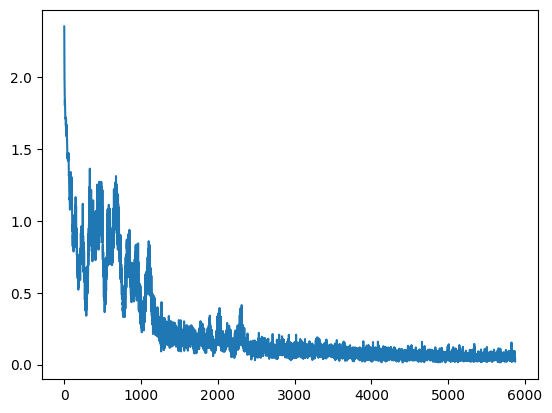

In [10]:
lenet.train()
losses = []
for i in range(num_epochs):
    lenet_optim.zero_grad()
    for x, y in trainloader:
        x = x.view(-1, 1, 28, 28)
        logits = lenet(x)
        lenet_loss = nn.CrossEntropyLoss()(logits, y)
        lenet_loss.backward()
        lenet_optim.step()
        lenet_schedule.step()
        losses.append(lenet_loss.item())

    if (i+1) % 10 == 0:
        print(f"Epoch {i+1}: lenet_loss {lenet_loss.item()}")
plt.plot(losses)

In [20]:
vae.train()
for i in range(num_epochs):
    for x, y in trainloader:
        vae.zero_grad()
        reconstruction, mu, log_var, latent = vae(x)
        recon_loss = nn.BCEWithLogitsLoss()(reconstruction, x)
        KL_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
        (recon_loss + 0.1*KL_loss).backward()
        vae_optim.step()
        vae_schedule.step()

    if (i+1) % 10 == 0:
        print(f"Epoch {i+1}: recon_loss {recon_loss.item()}")

Epoch 10: recon_loss 0.7195761799812317
Epoch 20: recon_loss 0.71937096118927
Epoch 30: recon_loss 0.7198279500007629
Epoch 40: recon_loss 0.7197105884552002
Epoch 50: recon_loss 0.7194605469703674


# Visualizing Encoders

## Regular Encoder

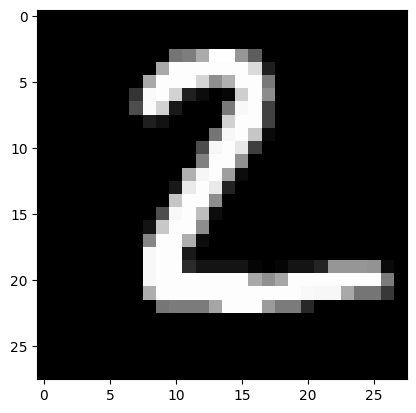

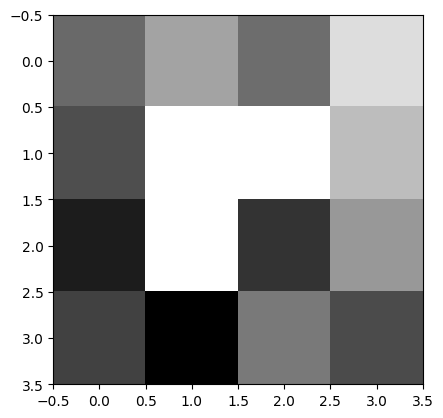

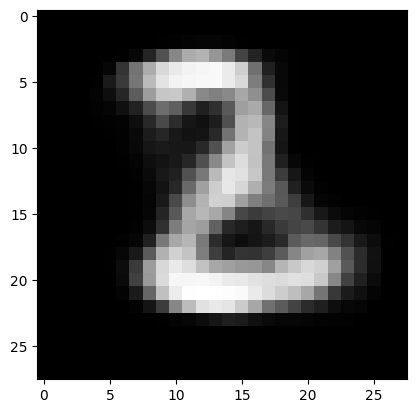

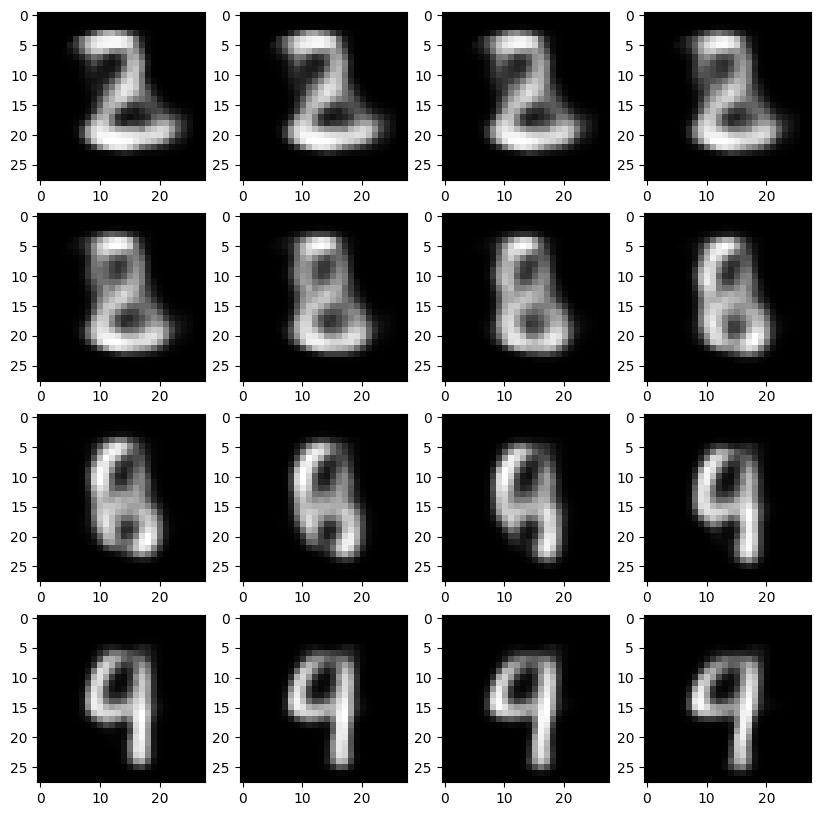

In [11]:
classifier.eval()
encoder.eval()
num_id = 1
other_id = 19
test_num, test_lbl = torch.tensor(test_data[num_id:num_id+1]), test_labels[num_id:num_id+1]
other_num, other_lbl = torch.tensor(test_data[other_id:other_id+1]), test_labels[other_id:other_id+1]
latent = encoder.batch_norm(encoder.encoder(test_num))
recon = torch.sigmoid(encoder(test_num))
other_latent = encoder.batch_norm(encoder.encoder(other_num))
other_recon = torch.sigmoid(encoder(other_num))
for img_data in [test_num, latent, recon]:
    side_len = int(np.sqrt(img_data.shape[-1]))
    plt.imshow(img_data.detach().numpy().reshape(side_len,side_len), cmap="gray")
    plt.show()
fig, axs = plt.subplots(4,4, figsize=(10,10))
axs = axs.flatten()
interp_elems = len(axs) - 1
for i, ax in enumerate(axs):
    cur_latent = ((interp_elems - i)/interp_elems * latent) + (i/interp_elems * other_latent)
    cur_decoded = torch.sigmoid(encoder.decoder(cur_latent))
    ax.imshow(cur_decoded.detach().numpy().reshape(28,28), cmap="gray")


## VAE Encoder

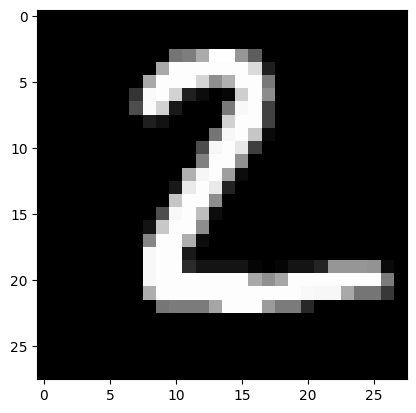

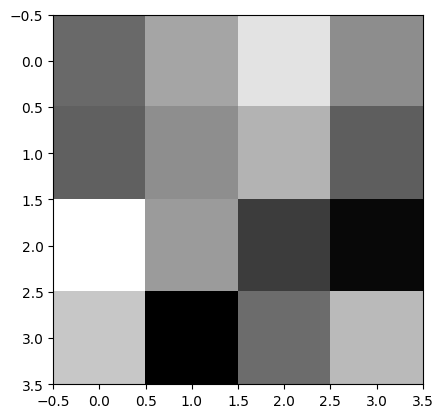

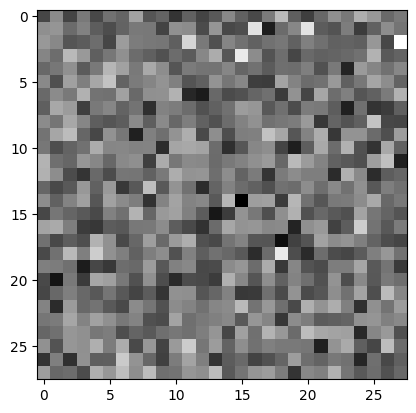

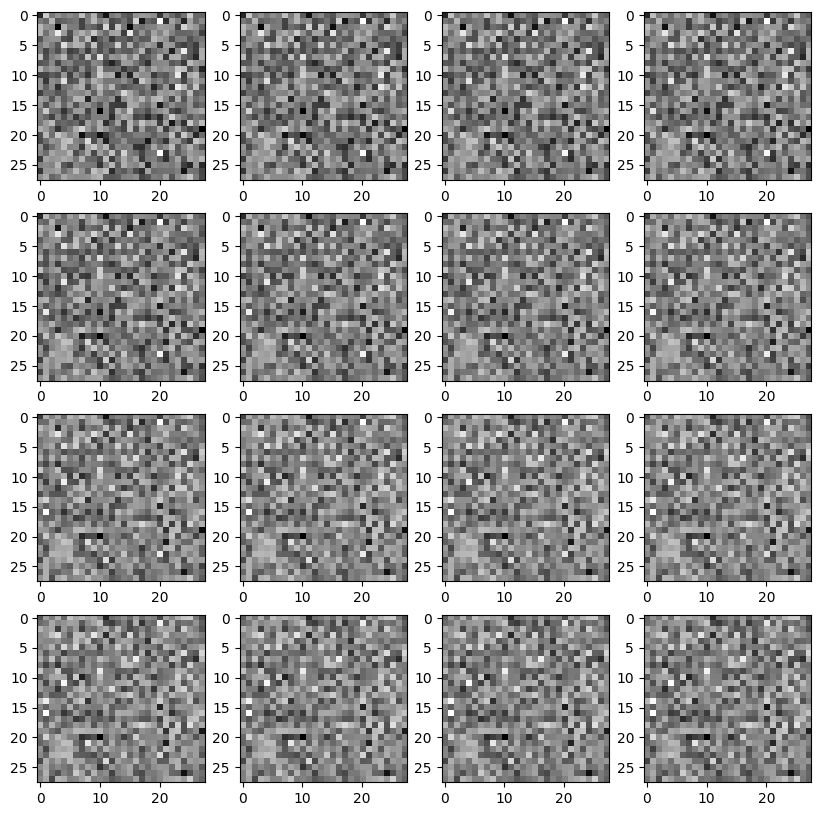

In [18]:
vae.eval()
num_id = 1
other_id = 19
test_num, test_lbl = torch.tensor(test_data[num_id:num_id+1]), test_labels[num_id:num_id+1]
other_num, other_lbl = torch.tensor(test_data[other_id:other_id+1]), test_labels[other_id:other_id+1]
recon, latent, mu, log_var = vae(test_num)
other_recon, other_latent, other_mu, other_log_var = vae(other_num)
for img_data in [test_num, latent, recon]:
    side_len = int(np.sqrt(img_data.shape[-1]))
    plt.imshow(img_data.detach().numpy().reshape(side_len,side_len), cmap="gray")
    plt.show()
fig, axs = plt.subplots(4,4, figsize=(10,10))
axs = axs.flatten()
interp_elems = len(axs) - 1
for i, ax in enumerate(axs):
    cur_latent = ((interp_elems - i)/interp_elems * latent) + (i/interp_elems * other_latent)
    cur_decoded = torch.sigmoid(vae.decoder(cur_latent))
    ax.imshow(cur_decoded.detach().numpy().reshape(28,28), cmap="gray")


In [12]:
correct = 0
for test_num, test_label in testloader:
    pred_label = torch.argmax(lenet(test_num.view(-1,1,28,28)), dim=1)
    lbls = torch.argmax(test_label, dim=1)
    correct += (pred_label == lbls).sum()
print(correct/len(test_data))

tensor(0.9827)


# Visualising lenet convolutions

In [13]:
def plot_feature_maps(conv: torch.Tensor):
    # conv: (1, C, H, W)
    maps = conv[0]                   # shape (C, H, W)
    C, H, W = maps.shape
    grid = int(np.ceil(np.sqrt(C)))
    fig, axs = plt.subplots(grid, grid, figsize=(10,10))
    axs = axs.flatten()

    for j in range(C):
        fmap = maps[j].detach().cpu().numpy()   # (H, W)
        axs[j].imshow(fmap, cmap="gray")
        axs[j].axis("off")

    # turn off any extra axes
    for ax in axs[C:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

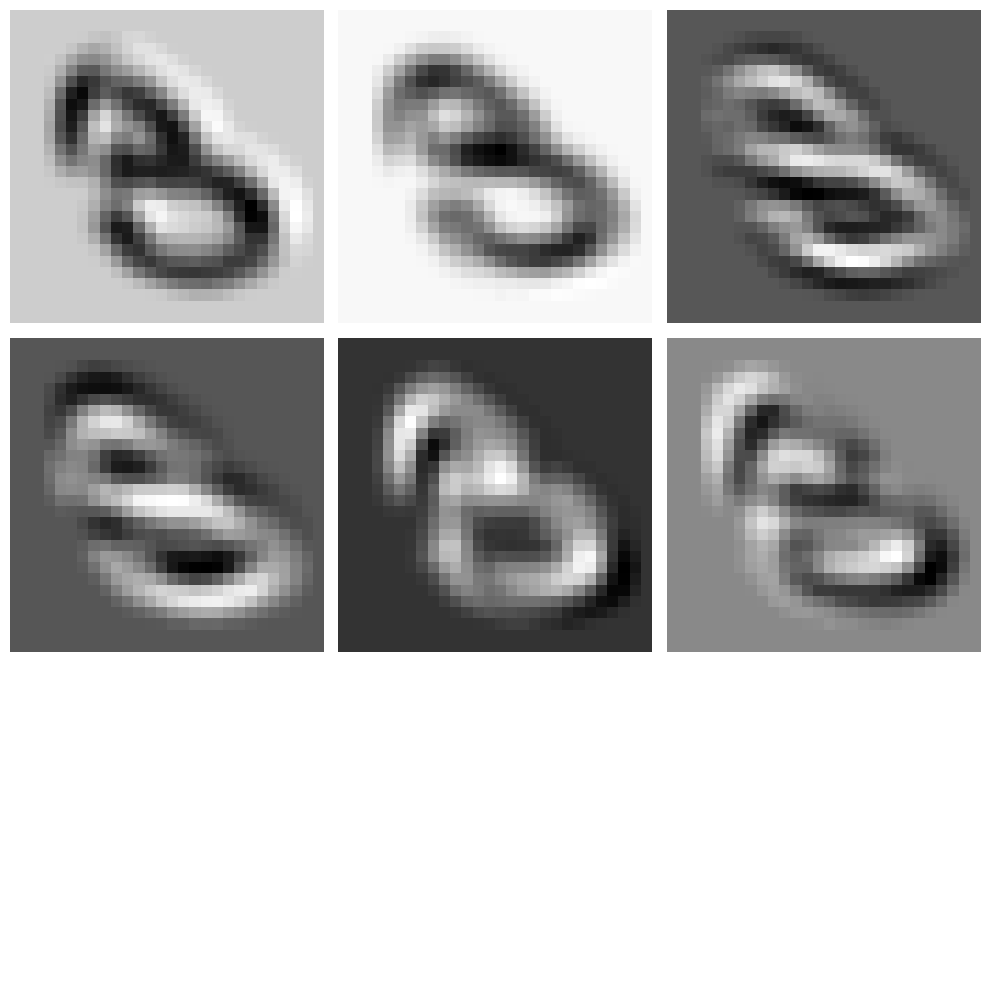

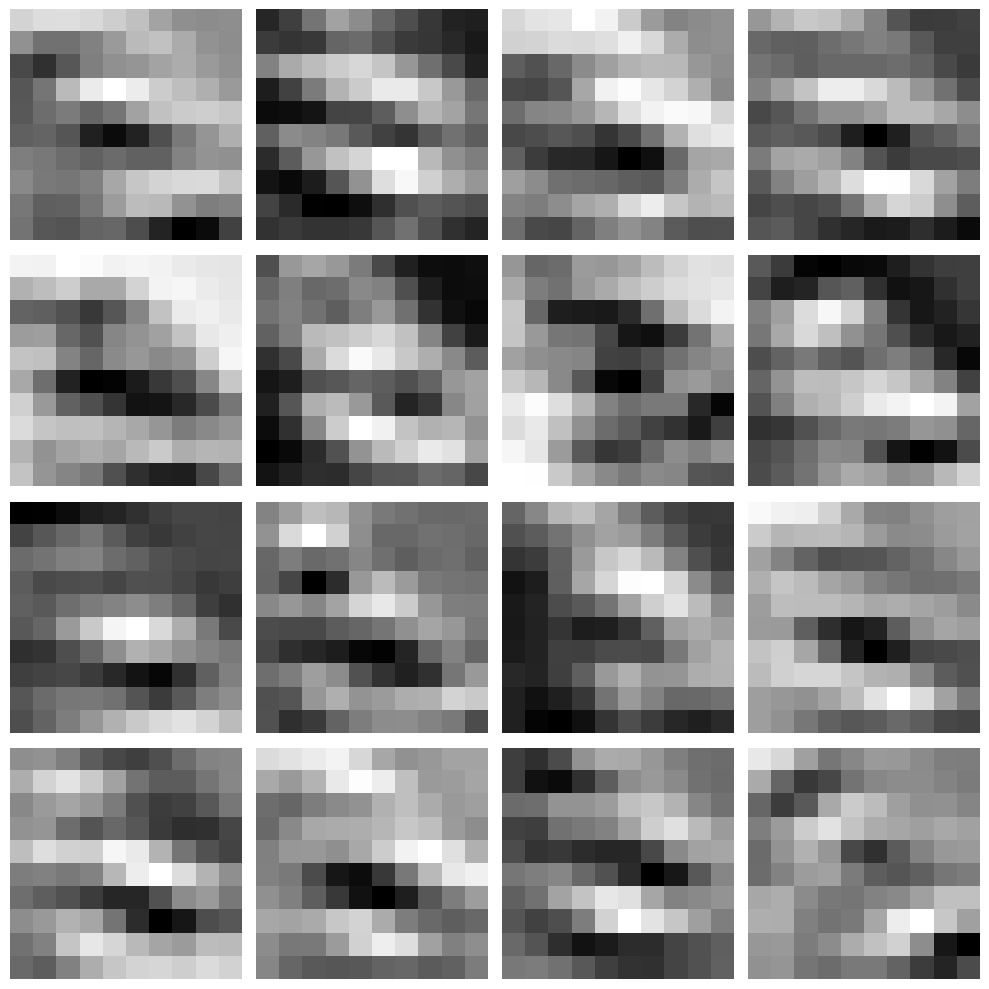

In [14]:
test_img = torch.tensor(test_data[18].reshape(1,1,28,28))
convs1 = lenet.conv1(test_img)
convs2 = lenet.conv2(lenet.pool1(torch.relu(lenet.bn1(convs1))))
# Then just call
plot_feature_maps(convs1)
plot_feature_maps(convs2)
# for conv in [convs1, convs2]:
#     num_convs = conv.shape[1]
#     figside = int(np.ceil(np.sqrt(num_convs)))
#     fig, axs = plt.subplots(figside, figside, figsize=(10,10))
#     axs = axs.flatten()
#     for i, subconv in enumerate(conv):
#         axs[i].imshow(subconv.detach().numpy().reshape(side_len,side_len), cmap="gray")
# plt.show()

In [15]:
test_labels[:30]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 